# 01 · Master results table

Per-(model, task) accuracy across the 10 models and 25 tasks reported in the paper (Table 2).
All scores are read from pre-computed evaluation files.


In [1]:
import nbtools as nb
from nbtools import (
    show_df, show_fig, show_md, show_tex,
    run_mod, run_live, heavy,
    REGEN, OUTPUTS_FINAL, OUTPUTS_DIR, PIPELINE_ROOT,
)
import pandas as pd
from IPython.display import display, HTML
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.1f}'.format)

# The 10 models evaluated in the paper (Table 2).
PAPER_MODELS = {
    'Claude Sonnet 4.6':   'claude-sonnet-4-6-cyberxpert',
    'GPT-5.4':             'gpt-5.4',
    'Gemma-4-31B':         'gemma-4-31B-it',
    'Qwen3.6-35B':         'Qwen3.6-35B-A3B',
    'Llama-3.3-70B':       'Llama-3.3-70B-Instruct',
    'GPT-OSS-20B':         'gpt-oss-20b',
    'Primus-Nemotron-70B': 'Llama-Primus-Nemotron-70B',
    'Primus-Merged-8B':    'Llama-Primus-Merged',
    'Foundation-Sec-8B':   'Foundation-Sec-8B-Instruct',
    'RedSage-Qwen3-8B':    'RedSage-Qwen3-8B-DPO',
}

print(f"Data root: {OUTPUTS_FINAL.name}/  — {'OK' if OUTPUTS_FINAL.exists() else 'MISSING'}")

Data root: outputs_final/  — OK


### Results table — 10 models × 25 tasks (paper Table 2)

In [2]:
import sys, json, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sys.path.insert(0, str(PIPELINE_ROOT))
from load_results import load_all_scores

all_scores = load_all_scores(OUTPUTS_FINAL)

# Paper model order
MODEL_ORDER = [
    ('Claude Sonnet 4.6',  'claude-sonnet-4-6-cyberxpert'),
    ('GPT-5.4',            'gpt-5.4'),
    ('Llama-3.3-70B',      'Llama-3.3-70B-Instruct'),
    ('Qwen3.6-35B',        'Qwen3.6-35B-A3B'),
    ('Primus-Nemotron-70B','Llama-Primus-Nemotron-70B'),
    ('RedSage-Qwen3-8B',   'RedSage-Qwen3-8B-DPO'),
    ('Foundation-Sec-8B',  'Foundation-Sec-8B-Instruct'),
    ('GPT-OSS-20B',        'gpt-oss-20b'),
    ('Primus-Merged',      'Llama-Primus-Merged'),
    ('Gemma-4-31B',        'gemma-4-31B-it'),
]

# GPT-5.4 SecEval: use corrected score (81.4%), not the broken 0.3%
from pathlib import Path
import re as _re
rerun = OUTPUTS_DIR / 'eval_results' / 'gpt-5.4_seceval_rerun' / 'seceval_result.json'
if rerun.exists():
    all_scores['gpt-5.4']['seceval'] = json.loads(rerun.read_text()).get('primary_score')

scores = {label: dict(all_scores.get(d, {})) for label, d in MODEL_ORDER}

# Load LightEval logprob + generative EM scores
LP_MAP  = {'cybersecurity_tools_cli':'lp_cli','cybersecurity_knowledge_frameworks':'lp_fw',
            'cybersecurity_knowledge_generals':'lp_gen','cybersecurity_tools_kali':'lp_kali',
            'cybersecurity_skills':'lp_skills','_average':'lp_avg'}
GEM_MAP = {'cybersecurity_tools_cli':'gem_cli','cybersecurity_knowledge_frameworks':'gem_fw',
            'cybersecurity_knowledge_generals':'gem_gen','cybersecurity_tools_kali':'gem_kali',
            'cybersecurity_skills':'gem_skills','_average':'gem_avg'}
for label, dir_name in MODEL_ORDER:
    le_dir = OUTPUTS_FINAL / dir_name / 'lighteval'
    for fname, kmap in [('redsage_logprob_result.json', LP_MAP),
                        ('redsage_generative_result.json', GEM_MAP)]:
        fpath = le_dir / fname
        if not fpath.exists(): continue
        for rkey, vals in json.loads(fpath.read_text()).get('results', {}).items():
            m = _re.search(':([^|]+)[|]', rkey)
            if m and m.group(1) in kmap:
                scores[label][kmap[m.group(1)]] = round(vals.get('acc', 0) * 100, 1)

# Task groups: (task_key, display_label, metric_note)
TASK_GROUPS = [
    ('CTI-Bench', [
        ('mcq',     'MCQ',     'Acc %'),
        ('rcm',     'RCM',     'Acc %'),
        ('vsp',     'VSP',     'MAD ↓'),
        ('ate',     'ATE',     'Acc %'),
        ('cti_taa', 'TAA',     'C+P %'),
    ]),
    ('AthenaBench', [
        ('ckt',        'CKT', 'Acc %'),
        ('rms',        'RMS', 'F1 %'),
        ('taa',        'TAA', 'Acc %'),
        ('athena_ate', 'ATE', 'Acc %'),
        ('athena_rcm', 'RCM', 'Acc %'),
        ('athena_vsp', 'VSP', 'MAD-norm %'),
    ]),
    ('SECURE', [
        ('secure_maet', 'MAET', 'Acc %'),
        ('secure_cwet', 'CWET', 'Acc %'),
        ('secure_kcv',  'KCV',  'Acc %'),
    ]),
    ('General', [
        ('seceval',          'SecEval',        'Acc %'),
        ('cybermetric',      'CyberMetric det','Acc %'),
        ('cybermetric_paper','CyberMetric samp','Acc %'),
        ('mmlu-cs',          'MMLU-CS gen',    'Acc %'),
        ('mmlu-cs-logprobs', 'MMLU-CS logp',   'Acc %'),
        ('secbench',         'SecBench',        'Acc %'),
    ]),
    ('RedSage-Bench (generative)', [
        ('redsage_cli',        'CLI',    'Acc %'),
        ('redsage_frameworks', 'FW',     'Acc %'),
        ('redsage_generals',   'GEN',    'Acc %'),
        ('redsage_kali',       'Kali',   'Acc %'),
        ('redsage_skills',     'Skills', 'Acc %'),
    ]),
    ('RedSage-Bench (logprob — official)', [
        ('lp_cli',    'CLI',   'Acc %'),
        ('lp_fw',     'FW',    'Acc %'),
        ('lp_gen',    'GEN',   'Acc %'),
        ('lp_kali',   'Kali',  'Acc %'),
        ('lp_skills', 'Skills','Acc %'),
        ('lp_avg',    'Avg.',  'Acc %'),
    ]),
    ('RedSage-Bench (generative EM)', [
        ('gem_cli',    'CLI',   'Acc %'),
        ('gem_fw',     'FW',    'Acc %'),
        ('gem_gen',    'GEN',   'Acc %'),
        ('gem_kali',   'Kali',  'Acc %'),
        ('gem_skills', 'Skills','Acc %'),
        ('gem_avg',    'Avg.',  'Acc %'),
    ]),
]

LOWER_BETTER = {'vsp'}
ARTIFACTS = {('Gemma-4-31B','rcm'), ('Primus-Nemotron-70B','secure_maet'),
             ('Primus-Nemotron-70B','secure_cwet'), ('Primus-Nemotron-70B','secure_kcv')}
API_MODELS = {'Claude Sonnet 4.6', 'GPT-5.4'}

model_labels = [m for m, _ in MODEL_ORDER]

# Build two parallel structures: numeric values + display strings
index_tuples, num_rows, str_rows, best_mask, artifact_mask = [], [], [], [], []
for bench, tasks in TASK_GROUPS:
    for task_key, task_name, metric in tasks:
        index_tuples.append((bench, f'{task_name}  [{metric}]'))
        row_vals = [scores[m].get(task_key) for m in model_labels]
        valid = [v for v in row_vals if v is not None]
        best  = (min(valid) if task_key in LOWER_BETTER else max(valid)) if valid else None
        prec  = 2 if task_key in LOWER_BETTER else 1
        num_rows.append(row_vals)
        str_rows.append([f'{v:.{prec}f}' if v is not None else '—' for v in row_vals])
        best_mask.append([v is not None and best is not None and abs(v - best) < 0.05
                          for v in row_vals])
        artifact_mask.append([(m, task_key) in ARTIFACTS for m in model_labels])

idx = pd.MultiIndex.from_tuples(index_tuples, names=['Benchmark', 'Task [Metric]'])
col_labels = [f'{c} ✦' if c in API_MODELS else c for c in model_labels]

# Display DataFrame with artifact markers baked into values
display_vals = []
for str_row, art_row in zip(str_rows, artifact_mask):
    display_vals.append([f'{s} †' if a and s != '—' else s
                         for s, a in zip(str_row, art_row)])

df_display = pd.DataFrame(display_vals, index=idx, columns=col_labels)

# Apply bold CSS to best-per-row cells
import numpy as np
best_arr = np.array(best_mask)

def bold_best(data):
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    for i in range(len(best_arr)):
        for j in range(len(best_arr[i])):
            if best_arr[i, j]:
                styles.iloc[i, j] = 'font-weight: bold'
    return styles

styled = df_display.style.apply(bold_best, axis=None)
print("bold = best per task  |  † = metric artifact  |  ✦ = closed/API model")
print("GPT-5.4 SecEval: corrected score 81.4% (original 0.3% was F2(I) token-budget failure)")
display(styled)

bold = best per task  |  † = metric artifact  |  ✦ = closed/API model
GPT-5.4 SecEval: corrected score 81.4% (original 0.3% was F2(I) token-budget failure)


### Per-benchmark average scores — model overview

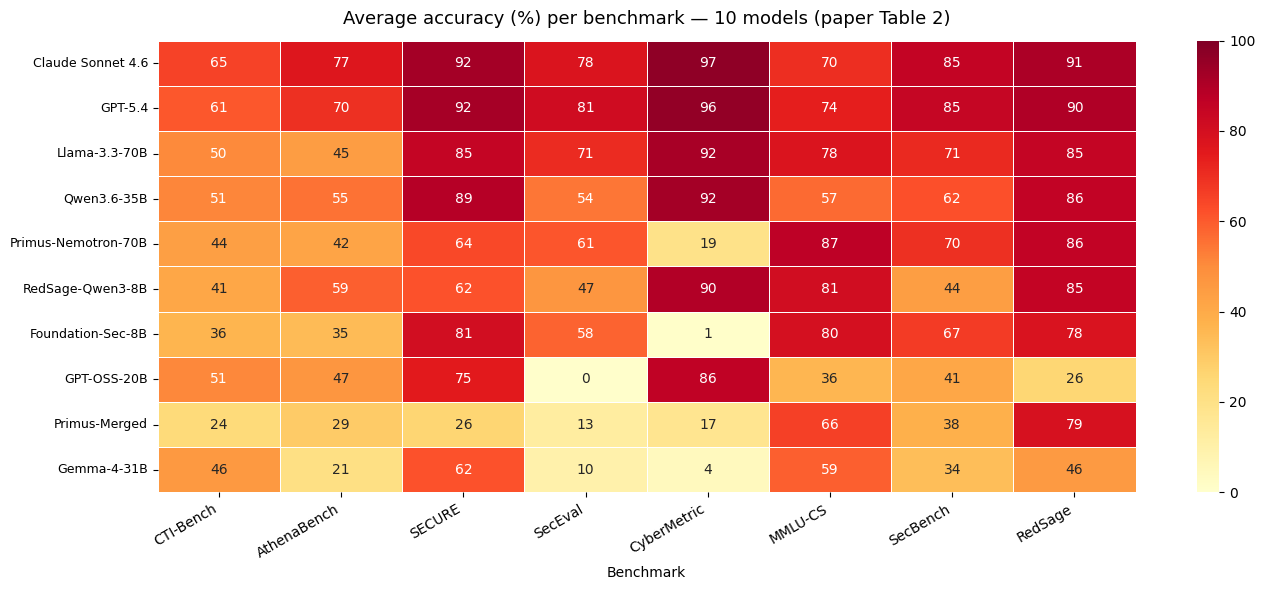

Note: Per-benchmark averages over accuracy tasks. VSP excluded (MAD scale).
CyberMetric = unified T=0. GPT-5.4 SecEval = corrected score (81.4%).


In [3]:
import numpy as np

# One representative score per benchmark per model (mean of accuracy tasks within each)
# Uses unified harness scores; VSP excluded (MAD scale); CyberMetric uses T=0 (unified)
BENCH_TASKS = {
    'CTI-Bench':   ['mcq', 'rcm', 'ate', 'cti_taa'],
    'AthenaBench': ['ckt', 'taa', 'athena_ate', 'athena_rcm', 'athena_vsp'],
    'SECURE':      ['secure_maet', 'secure_cwet', 'secure_kcv'],
    'SecEval':     ['seceval'],
    'CyberMetric': ['cybermetric'],
    'MMLU-CS':     ['mmlu-cs'],
    'SecBench':    ['secbench'],
    'RedSage':     ['redsage_cli','redsage_frameworks','redsage_generals',
                    'redsage_kali','redsage_skills'],
}

avg_rows = []
for label, _ in MODEL_ORDER:
    row = {'Model': label}
    for bench, tasks in BENCH_TASKS.items():
        vals = [scores[label].get(t) for t in tasks if scores[label].get(t) is not None]
        row[bench] = round(np.mean(vals), 1) if vals else None
    avg_rows.append(row)

avg_df = pd.DataFrame(avg_rows).set_index('Model').apply(pd.to_numeric, errors='coerce')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(avg_df, cmap='YlOrRd', annot=True, fmt='.0f',
            annot_kws={'size': 10}, linewidths=0.5, vmin=0, vmax=100, ax=ax,
            linecolor='white')
ax.set_title('Average accuracy (%) per benchmark — 10 models (paper Table 2)', fontsize=13, pad=12)
ax.set_xlabel('Benchmark', fontsize=10)
ax.set_ylabel('')
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=9)
plt.tight_layout(); plt.show()
print("Note: Per-benchmark averages over accuracy tasks. VSP excluded (MAD scale).")
print("CyberMetric = unified T=0. GPT-5.4 SecEval = corrected score (81.4%).")

### Known metric artifacts — denominator inflation

In [4]:
from load_results import real_score

ARTIFACTS = {
    ('Gemma-31B',  'rcm'):         '998/1000 invalid → reported 100%, real 0.2% (×500)',
    ('Nemo-70B',   'secure_maet'): '971/1072 empty → MAET inflated',
    ('Nemo-70B',   'secure_cwet'): '873/964 empty → reported 100%, real 9.4% (×11)',
}
art_rows = []
for (m, t), note in ARTIFACTS.items():
    art, real = real_score(m, t)
    art_rows.append({
        'Model': m, 'Task': t,
        'Reported (correct/valid)': f"{art:.1f}%" if art else '—',
        'Real (correct/total)':     f"{real:.1f}%" if real else '—',
        'Note': note,
    })
art_df = pd.DataFrame(art_rows)
print(art_df.to_string(index=False))

    Model        Task Reported (correct/valid) Real (correct/total)                                               Note
Gemma-31B         rcm                   100.0%                 0.2% 998/1000 invalid → reported 100%, real 0.2% (×500)
 Nemo-70B secure_maet                    91.1%                 8.6%                     971/1072 empty → MAET inflated
 Nemo-70B secure_cwet                   100.0%                 9.4%     873/964 empty → reported 100%, real 9.4% (×11)


### LaTeX results table — `gen_table.py`
The `tab:main_results` block used in the paper. Note: `gen_table.py` reads all 12 entries in `outputs_final/` (including Fanar and Qwen3-30B) as written by the paper authors; the caption reflects the full 12-model run used in the paper.

In [5]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, str(PIPELINE_ROOT / 'gen_table.py')],
    capture_output=True, text=True
)
if result.returncode == 0:
    print(result.stdout)
else:
    print("[error]", result.stderr[:500])

% ---------------------------------------------------------------
% Main results table
% * = API/closed model   dag = known metric artifact
% ---------------------------------------------------------------
\begin{table*}[t]
\centering
\setlength{\tabcolsep}{4pt}
\caption{Evaluation results across 12 models and 25 tasks on five cybersecurity benchmark families. \textbf{Bold}~=~best per task. Superscripts denote metric type: \textsuperscript{Acc}~accuracy (\%); \textsuperscript{F1}~macro-F1 (\%); \textsuperscript{MAD$\downarrow$}~mean absolute deviation of CVSS base score (lower is better, \textbf{bold}~=~lowest); \textsuperscript{MAD-norm}~AthenaBench normalised MAD accuracy $= \max(0,1-\text{MAD}/7.7)\times 100$~(\%); \textsuperscript{C+P}~CTI-Bench correct-and-plausible accuracy via alias-graph BFS~(\%). \textsuperscript{*}~closed/API model (no logprob evaluation). \ensuremath{^\dagger}~metric artifact: invalid predictions excluded from denominator (Gemma RCM: 998/1000 invalid~$\to$~r